Día   : 492 eventos
Noche : 621 eventos


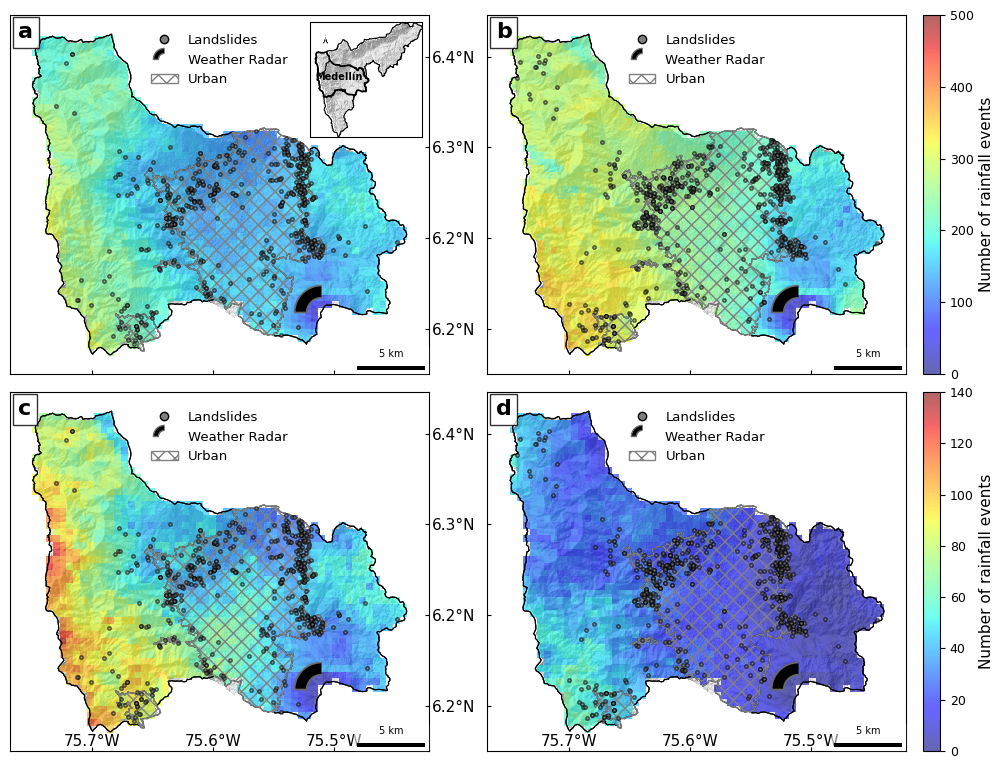

In [ ]:

import pandas as pd
import numpy as np
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker

from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes   # NUEVO
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

def hillshade(dem, sun_elevation=45, sun_azimuth=315):
    """
    Calcula el sombreado del terreno a partir del modelo de elevación digital.

    Args:
        sun_elevation (float): Elevación solar en grados.
        sun_azimuth (float): Azimut solar en grados.

    Returns:
        ndarray: Sombreado del terreno.
    """
    
    dem = dem[0].values
    
    sun_elevation = np.radians(sun_elevation)
    sun_azimuth = np.radians(sun_azimuth)

    slope = np.arctan(np.sqrt(np.square(np.gradient(dem)[0]) + np.square(np.gradient(dem)[1])))
    aspect = np.arctan2(-np.gradient(dem)[0], np.gradient(dem)[1])

    hillshade = 255 * ((np.cos(sun_elevation) * np.cos(slope)) +
                        (np.sin(sun_elevation) * np.sin(slope) * np.cos(aspect - sun_azimuth))) / 2 + 128
    
    return hillshade


def filter_and_interpolate_data(radar_file, coord_file):
    """
    Filtra los datos de un archivo netCDF basados en las coordenadas proporcionadas en un archivo CSV
    y luego interpola los valores faltantes.
    
    Args:
        radar_file: str - Ruta al archivo netCDF con los datos de eventos de lluvia.
        coord_file: str - Ruta al archivo CSV que contiene las coordenadas a excluir (columnas 'lon' y 'lat').
    
    Returns:
        interpolated_ds: xarray.Dataset - Datos interpolados luego de aplicar la máscara de exclusión.
    """
    
    coords_df = pd.read_csv(coord_file)
    
    selected_lons = coords_df['lon'].values
    selected_lats = coords_df['lat'].values
    
    data = xr.open_dataset(radar_file)
    
    mask = xr.DataArray(np.ones((len(data.lon), len(data.lat)), dtype=bool), 
                        coords=[data.lon, data.lat], dims=["lon", "lat"])

    for lon_val, lat_val in zip(selected_lons, selected_lats):
        nearest_lon = data.sel(lon=lon_val, method='nearest').lon.values
        nearest_lat = data.sel(lat=lat_val, method='nearest').lat.values
        mask.loc[nearest_lon, nearest_lat] = False  # Marcar como False las coordenadas más cercanas
    
    data_filtrado = data.where(mask, drop=True)
    
    interpolated_ds = data_filtrado.interpolate_na(dim='lon', method='linear')
    interpolated_ds = interpolated_ds.interpolate_na(dim='lat', method='linear')
    
    return interpolated_ds

def cut_with_polygon(data, poligono):
    """
    Recorta un conjunto de datos con un polígono.

    Args:
        data (xarray.DataArray): Datos a recortar.
        poligono (geopandas.GeoDataFrame): Polígono con el que se recortarán los datos.
    
    Returns:
        xarray.DataArray: Datos recortados.
    """
    shapes = [poligono.geometry[0]]
    data = data.rio.set_crs("EPSG:4326")  # Establecer el CRS si no está establecido
    data = data.rio.set_spatial_dims(x_dim="lon", y_dim="lat") 
    data_recortada = data.rio.clip(shapes, data.rio.crs, drop=True)
    return data_recortada

def radar_marker(inner=0.55, n=40):
    """
    Devuelve un Path que describe un anillo de 90° ( simbolo de radar QGIS).

    inner : radio interior (0-1)  → controla el grosor
    n     : número de vértices por arco
    """
    # arco exterior 270°→360° (matplotlib usa rad y sentido antihorario)
    theta_ext = np.linspace(3*np.pi/2, 2*np.pi, n)
    outer = np.c_[np.cos(theta_ext), np.sin(theta_ext)]

    # arco interior 360°→270° (mismo sentido, radio más pequeño)
    theta_int = np.linspace(2*np.pi, 3*np.pi/2, n)
    inner_ = inner * np.c_[np.cos(theta_int), np.sin(theta_int)]

    verts  = np.vstack([outer, inner_, outer[0]])        # cerrar polígono
    codes  = np.full(len(verts), Path.LINETO)
    codes[0] = codes[-1] = Path.MOVETO

    return Path(verts, codes)

def _draw_panel(ax, sombra, bounds, data_clip, 
                gdf_poly, gdf_ls, cmap, vmin,
                vmax, ticks, nombre_variable, radar_csv_path,
                letter, add_cbar=False,
                urb=None, rur=None):
    
    xmin, ymin, xmax, ymax = bounds
    dx, dy = (xmax-xmin)*0.06, (ymax-ymin)*0.06
    ax.set_xlim(xmin-dx, xmax+dx)
    ax.set_ylim(ymin-dy, ymax+dy)

    ax.imshow(np.flipud(sombra), cmap='gray', origin='lower',
              extent=[xmin, xmax, ymin, ymax], alpha=0.5, zorder=0)
    pcm = ax.pcolormesh(data_clip['lon'], data_clip['lat'], data_clip.T,
                        cmap=cmap, shading='auto',
                        vmin=vmin, vmax=vmax, alpha=0.6, zorder=1)
    



    gdf_poly.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8, zorder=2)
    gdf_ls.plot(ax=ax, marker='o', color='gray', edgecolor='k', facecolor='gray',
                markersize=6, alpha=0.6, zorder=3)
    
    radar_df  = pd.read_csv(radar_csv_path,)
    radar_gdf = gpd.GeoDataFrame(
        radar_df,
        geometry=gpd.points_from_xy(radar_df.longitud, radar_df.latitud),
        crs="EPSG:4326"
    )
    
    radar_path = radar_marker() 
    radar_ms = MarkerStyle(radar_path)
    radar_ms._transform.rotate_deg(180)

    radar_gdf.plot(ax=ax, marker=radar_ms, markersize=1500, facecolor='black',
                edgecolor='dimgray', linewidth=1.2, label='Weather Radar', zorder=5)

    # ------------------------------------------------------------------
    # NUEVO: suelo rural/urbano (urbano achurado, rural transparente)
    # ------------------------------------------------------------------
    if rur is not None and len(rur) > 0:
        # rural: solo borde (transparente)
        rur.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8, zorder=2)

    if urb is not None and len(urb) > 0:
        # urbano: sin relleno (transparente) + achurado
        # Nota: hatch funciona mejor cuando facecolor='none' y linewidth pequeño
        urb.plot(ax=ax,
                 facecolor="none",
                 edgecolor="gray",
                 linewidth=0.8,
                 hatch="xx",
                 zorder=2)

                #    color='limegreen',
                # markersize=220,
                # edgecolor='black', linewidth=0.6, label='Weather Radar',
                # zorder = 5)
    
    handles, labels = ax.get_legend_handles_labels()

    handle_landslides = Line2D([], [], marker='o', linestyle='None',
                            markerfacecolor='gray', markeredgecolor='black',
                            markersize=6,
                            label='Landslides')       # un poco más grande
    handle_radar = Line2D([], [], marker=radar_ms, linestyle='None',
                        markerfacecolor='black', markeredgecolor='dimgray',
                        markersize=16,        # un poco más pequeño
                        label='Weather Radar')
    

    handle_urban = Patch(facecolor="none", edgecolor="gray", hatch="xx", label="Urban")

    new_handles, new_labels = [], []
    for h, lab in zip(handles, labels):
        if lab not in ('Landslides', 'Weather Radar', 'Urban'):
            new_handles.append(h)
            new_labels.append(lab)

    new_handles.extend([handle_landslides, handle_radar, handle_urban])
    new_labels.extend(['Landslides', 'Weather Radar', 'Urban'])

    ax.text(0.02, 0.98, letter, transform=ax.transAxes, 
            fontsize=16, fontweight='bold', va='top', 
            ha='left', bbox=dict(facecolor='white', alpha=0.8))

    ax.legend(new_handles, new_labels,
            loc='upper center', bbox_to_anchor=(0.5, 0.98),
            fontsize=9.5, frameon=False)

    ax.xaxis.set_major_locator(mticker.MaxNLocator(4))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(4))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):.1f}°W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}°N"))
    ax.tick_params(axis='both',
                    direction='in',   # ticks apuntan al interior
                    pad=-12,           # nº negativo = empuja la etiqueta dentro
                    length=3,         # largo de la marca (opcional)
                    labelsize=11)
    ax.set_aspect('equal')

    ax.add_artist(ScaleBar(111_320, length_fraction=0.25,
                           location='lower right', scale_loc='top',
                           box_alpha=0.5, font_properties={'size': 7}))


    if add_cbar:
        cax = inset_axes(ax, width="4%", height="100%",       # 4 % del eje, 55 % de la altura
                         loc="center right",
                         bbox_to_anchor=(0.08, 0., 1, 1),    # pequeña separación: 
                         bbox_transform=ax.transAxes,
                         borderpad=0)
        cbar = plt.colorbar(pcm, cax=cax)
        cbar.set_label(nombre_variable, fontsize=11)
        cbar.ax.tick_params(labelsize=9)

radar_events = '../DATA/rainfall/radar/'
landslide_events = '../DATA/landslides/'
output_figures = '../FIGURES/spatial_analysis/radar/'
radar_dir   = '../DATA/rainfall/radar/'      # ⇠ ajusta rutas
shapefile   = '../DATA/shape_files/med.geojson'
aburra      = '../DATA/shape_files/aburra.geojson'
#shapefile   = '/home/oisanchezp/Geociencias/shape_files/amva.geojson'
#dem_file    = '/home/oisanchezp/Geociencias/shape_files/dem_amva_12.tif'

#------------SHAPEFILE DE SUELO URBANO Y SUELO RURAL---------------
suelo = '../DATA/shape_files/Clasificacion_del_Suelo.shp'


suelo_gdf = gpd.read_file(suelo).to_crs("EPSG:4326")

aoi = gpd.GeoDataFrame(geometry=[suelo_gdf.unary_union], crs=suelo_gdf.crs)

aoi["geometry"] = aoi.buffer(0)

gpoly = aoi
bounds = gpoly.total_bounds

suelo_gdf["CLASE_SUEL"] = suelo_gdf["CLASE_SUEL"].astype(str).str.strip()

suelo_urb = suelo_gdf[suelo_gdf["CLASE_SUEL"].isin(["Urbano", "Expansión Urbana"])].copy()
suelo_rur = suelo_gdf[suelo_gdf["CLASE_SUEL"].isin(["Rural"])].copy()

urb = gpd.GeoDataFrame(geometry=[suelo_urb.unary_union], crs=suelo_gdf.crs)
rur = gpd.GeoDataFrame(geometry=[suelo_rur.unary_union], crs=suelo_gdf.crs)

#----------------------------------------------------------------

dem_file   = '../DATA/shape_files/dem_12_med.tif'
dem_aburra = '../DATA/shape_files/dem_aburra_12.tif'
salida_png  = '../FIGURES/spatial_analysis/radar/mapa_num_events_night_day.png'

# Deslizamientos ya filtrados por día / noche arriba
landslides_dagrd = f'{landslide_events}inventory_SIATA.csv'
#landslides_dagrd = f'{landslide_events}bd_eventos_dagrd.csv'
#landslides_dagrd = "/home/oisanchezp/Thesis/data/processed/slope_units_eventos.csv"
#landslides_dagrd = f'{landslide_events}inventory_DAGRD.csv'
landslides_df = pd.read_csv(landslides_dagrd)
#filtrar por columna municipio, solo medellín
landslides_df = landslides_df[landslides_df['municipio'] == 'Medellín']
#landslides_df = landslides_df[landslides_df['evento_materializado'] == 'si']
#landslides_df = landslides_df[landslides_df['tipo_incidente'].isin(['Movimiento en masa', 'Avenida torrencial', 'Estructural', 'Otros'])]
#landslides_df['fecha_ocurrencia'] = pd.to_datetime(landslides_df['fecha_ocurrencia'])
landslides_df['fecha_hora_evento'] = pd.to_datetime(landslides_df['fecha_hora_evento'])
#eliminar un una fila que tiene 'objectid' = 8056, 9729, 9321, 9283, 9262, 9219, 9210, 9204, 9111, 8056,8123
# 8165, 8333, 8384, 8508, 8564, 8636, 8695, 8752, 8791, 8880, 9070
#obid = [8056, 9729, 9321, 9283, 9262, 9219, 9210, 9204, 9111, 8123,
#         8165, 8333, 8384, 8508, 8564, 8636, 8695, 8752, 8791, 8880, 9070, 9321]
#landslides_df = landslides_df[~landslides_df['objectid'].isin(obid)]
# #elimnar filas que tengan las coordenadas de latitud y longitud iguales a coords = [6,221784332688069, -75,70390170493522]
coords = [6.221784332688069, -75.70390170493522]
landslides_df = landslides_df[~((landslides_df['latitud'] == coords[0]) & (landslides_df['longitud'] == coords[1]))]

landslides_df['hora'] = landslides_df['fecha_hora_evento'].dt.hour

landslides_df = landslides_df[~landslides_df['hora'].isin([0, 12])]

eventos_dia = landslides_df[(landslides_df['hora'] >= 6) & (landslides_df['hora'] < 18)].copy()
eventos_noche = landslides_df[(landslides_df['hora'] >= 18) | (landslides_df['hora'] < 6)].copy()

print(f"Día   : {len(eventos_dia)} eventos")
print(f"Noche : {len(eventos_noche)} eventos")

def to_gdf(df, crs='EPSG:4326'):
    return gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df.longitud, df.latitud),
        crs=crs
    )

gdf_dia   = to_gdf(eventos_dia)
gdf_noche = to_gdf(eventos_noche)

ds_dia_0_15   = f'{radar_dir}eventos_lluvia_5mm_1horas_dia_intensidad_0_15.nc'
ds_noche_0_15 = f'{radar_dir}eventos_lluvia_5mm_1horas_noche_intensidad_0_15.nc'
ds_dia_15p    = f'{radar_dir}eventos_lluvia_5mm_1horas_dia_intensidad_15_plus.nc'
ds_noche_15p  = f'{radar_dir}eventos_lluvia_5mm_1horas_noche_intensidad_15_plus.nc'

coord_file = f'{radar_events}coordenadas_que_no.csv'

ds_dia_0_15 = filter_and_interpolate_data(ds_dia_0_15, coord_file)
ds_noche_0_15 = filter_and_interpolate_data(ds_noche_0_15, coord_file)
ds_dia_15p = filter_and_interpolate_data(ds_dia_15p, coord_file)
ds_noche_15p = filter_and_interpolate_data(ds_noche_15p, coord_file)

#gpoly = gpd.read_file(shapefile)

data_recortada = cut_with_polygon(ds_noche_15p['num_eventos'], gpoly)
data_recortada = data_recortada.where(data_recortada >= 0)


panels = [
('Day 0-15 mm h⁻¹',   ds_dia_0_15,  gdf_dia,   [0,100,200,300,400,500], 'a'),
('Night 0-15 mm h⁻¹', ds_noche_0_15,gdf_noche,[0,100,200,300,400,500], 'b'),
('Day >15 mm h⁻¹',    ds_dia_15p,   gdf_dia,   [0,20,40,60,80,100,120,140], 'c'),
('Night >15 mm h⁻¹',  ds_noche_15p, gdf_noche,[0,20,40,60,80,100,120,140], 'd'),
]

radar_csv_path = f'../DATA/coords_radar.csv'  # ruta al CSV del radar

dem = rioxarray.open_rasterio(dem_file, mask_and_scale=True)

valle = gpd.read_file(aburra)  # Valle de Aburrá


# ───────────────────────── 1. NUEVA DISTRIBUCIÓN ──────────────────────────
fig = plt.figure(figsize=(11.5, 8))
gs  = gridspec.GridSpec(
        2, 2,                      # 2 filas × 2 columnas (todos iguales)
        wspace=0, hspace=0.05,
        left=0.05, right=0.88,
        top=0.97, bottom=0.05)

map_axes = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(2)]

# ───────────────────── 2. DIBUJA LOS 4 MAPAS COM0 SIEMPRE ─────────────────
for i, (ax, (titulo, ds, gdf_ls_panel, ticks, letter)) in enumerate(
        zip(map_axes, panels)):

    data_rec = cut_with_polygon(ds['num_eventos'], gpoly).where(lambda x: x >= 0)
    dem2     = dem.rio.reproject(gpoly.crs)
    sombra   = hillshade(dem2)
    bounds   = gpoly.total_bounds
    vmax     = 500 if '0-15' in titulo else 140
    add_cbar = (i % 2 == 1)                    # solo en la col. derecha

    _draw_panel(ax, sombra, bounds, data_rec,
                gpoly, gdf_ls_panel,
                cmap='jet', vmin=0, vmax=vmax, ticks=ticks,
                nombre_variable='Number of rainfall events',
                radar_csv_path=radar_csv_path,
                letter=letter, add_cbar=add_cbar,
                urb=urb, rur=rur)

    if i < 2:
        ax.tick_params(axis='x', labelbottom=False)
    if i % 2 == 0:
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position('right')
        ax.tick_params(axis='y',
                       labelleft=False, labelright=True, pad=2)
    else:
        ax.tick_params(axis='y', labelleft=False, labelright=False)


    # ───────────────── 3. INSET DEL MAPA DE UBICACIÓN EN PANEL “a” ─────────────
dem_aburra  = rioxarray.open_rasterio(dem_aburra, mask_and_scale=True)\
                         .rio.reproject(valle.crs)
sombra_abur = hillshade(dem_aburra)
xmin, ymin, xmax, ymax = valle.total_bounds
cmap_gray   = plt.cm.gray.copy(); cmap_gray.set_bad('none')

loc_ax = inset_axes(map_axes[0],       # panel “a”
                    width="32%", height="32%",
                    loc='upper right',
                    bbox_to_anchor=(0.01,-0.02, 1, 1),
                    bbox_transform=map_axes[0].transAxes,
                    borderpad=0)

loc_ax.imshow(np.flipud(sombra_abur), cmap=cmap_gray, origin='lower',
              extent=[xmin, xmax, ymin, ymax],
              alpha=0.5, zorder=0)
valle.boundary.plot(ax=loc_ax, edgecolor='black', linewidth=0.8)
gpoly.boundary.plot(ax=loc_ax, edgecolor='black', linewidth=1.2)

centro = gpoly.geometry.unary_union.centroid
loc_ax.text(centro.x, centro.y, "Medellín",
            ha='center', va='center',
            fontsize=7, fontweight='bold')

loc_ax.set_xticks([]); loc_ax.set_yticks([])
loc_ax.set_aspect('equal')

img = plt.imread(f'{radar_events}norte.png')
loc_ax.add_artist(
    AnnotationBbox(OffsetImage(img, zoom=0.01, resample=True),
                   xy=(0.13, 0.85), xycoords='axes fraction',
                   pad=0, bboxprops=dict(edgecolor='white')))

#plt.savefig(salida_png, dpi=300, bbox_inches='tight')
plt.show()